<a href="https://colab.research.google.com/github/AnalysiswithIcke/PortfolioProjects/blob/main/Financial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Veri çekmek ve analiz etmek için araçlarımızı indiriyoruz
!pip install yfinance pandas ta matplotlib

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from ta.trend import SMAIndicator # Basit Hareketli Ortalama için

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=308cace8e623c4ef1666a5ea4c082db8cc713bb85eb11f1198f4d7bad991aa22
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [13]:
import yfinance as yf
import pandas as pd

# 1. Veriyi Çek (Örn: Türk Hava Yolları - THYAO)
hisse_adi = "THYAO.IS"

# Başlangıç tarihini 2023 veya 2024 yapalım ki elimizde bol veri olsun
df = yf.download("THYAO.IS", start="2023-01-01", end="2026-03-20")

# ÖNEMLİ: Veriyi çektikten sonra önceki hücreleri (indikatör hesaplama)
# tekrar yukarıdan aşağıya doğru sırayla çalıştır.

# 2. İlk 5 satıra bakalım
print(df.head())

/tmp/ipykernel_7750/3108862638.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("THYAO.IS", start="2023-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker        THYAO.IS    THYAO.IS    THYAO.IS    THYAO.IS  THYAO.IS
Date                                                                
2023-01-02  143.406601  143.699669  138.815248  139.108302  60745183
2023-01-03  143.992737  146.923390  143.015853  144.871942  73564352
2023-01-04  141.159775  144.774244  140.280585  144.481175  50055440
2023-01-05  138.522171  143.797339  137.056845  141.452823  66261587
2023-01-06  139.206009  140.866709  129.339472  132.074751  84430370


/tmp/ipykernel_7750/2800251701.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(hisse, start="2025-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed


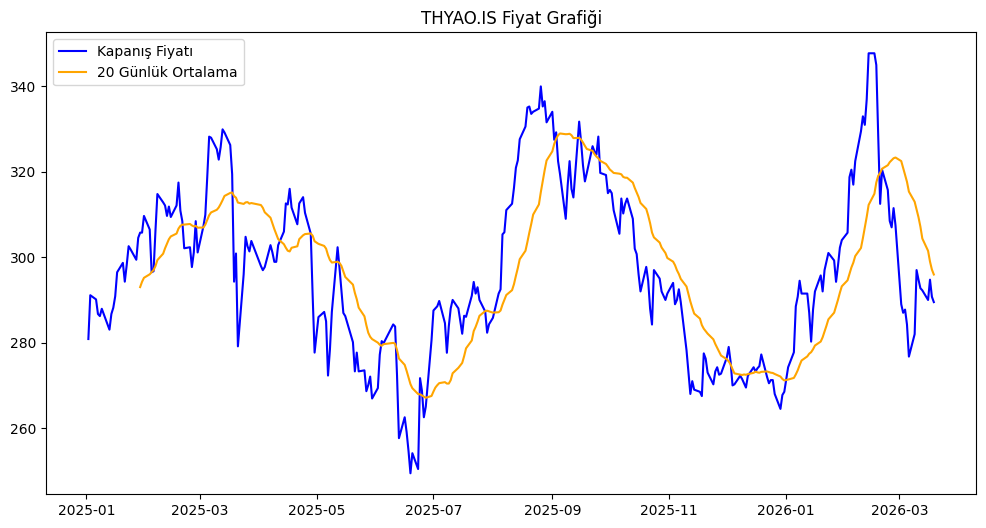

In [14]:
# Hisse sembolünü belirliyoruz
hisse = "THYAO.IS"

# Veriyi Yahoo Finance'den çekiyoruz
df = yf.download(hisse, start="2025-01-01", end="2026-03-20")

# Basit bir analiz: 20 günlük Hareketli Ortalama hesapla
df['SMA20'] = df['Close'].rolling(window=20).mean()

# Grafiğe dökelim
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Kapanış Fiyatı', color='blue')
plt.plot(df['SMA20'], label='20 Günlük Ortalama', color='orange')
plt.title(f"{hisse} Fiyat Grafiği")
plt.legend()
plt.show()

In [15]:
# 1. RSI (Göreceli Güç Endeksi) Hesaplama
# RSI, hissenin 'pahalı' mı yoksa 'ucuz' mu olduğunu anlamamıza yardım eder.
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1  + rs))

# 2. Hedef Belirleme (Yapay zekanın neyi tahmin edeceğini söylüyoruz)
# 'Target' sütunu: Eğer yarınki fiyat bugünkü fiyattan yüksekse 1, düşükse 0 olsun.
# Biz yapay zekaya "Yarın yükselecek mi, düşecek mi?" sorusunu öğreteceğiz.
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 3. Boş verileri temizle (Hesaplamalardan dolayı ilk satırlar boş kalır)
df.dropna(inplace=True)

# Bakalım tablomuz nasıl görünüyor?
print(df[['Close', 'RSI', 'Target']].tail())

Price         Close        RSI Target
Ticker     THYAO.IS                  
Date                                 
2026-03-13   292.25  34.228188      0
2026-03-16   290.00  36.690647      1
2026-03-17   294.75  41.580756      0
2026-03-18   290.75  35.640138      0
2026-03-19   289.50  37.050360      0


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Yapay zekanın kullanacağı ipuçları: RSI ve Kapanış Fiyatı
ozellikler = ['Close', 'RSI']

# Veriyi Eğitim ve Test olarak ikiye bölelim
# (Son 20 günü test için ayıralım, geri kalanıyla öğrensin)
train = df.iloc[:-20]
test = df.iloc[-20:]

# Modeli oluştur ve eğit
model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(train[ozellikler], train['Target'])

# Test verisi üzerinde tahmin yap
tahminler = model.predict(test[ozellikler])

# Başarı oranını ölçelim
skor = accuracy_score(test['Target'], tahminler)
print(f"Modelin Doğruluk Oranı: %{skor * 100}")

Modelin Doğruluk Oranı: %60.0


In [17]:
def yorum_yaz(tahmin, veri, dogruluk_skoru):
    # .item() ekleyerek numpy array'den saf sayıya dönüştürüyoruz
    fiyat = veri['Close'].values[0].item()
    rsi = veri['RSI'].values[0].item()

    skor = round(dogruluk_skoru * 100, 2)

    # Geri kalan kodlar aynı kalacak...
    yorum = f"📊 THY (THYAO) İÇİN AI ANALİZ RAPORU\n"
    yorum += f"---------------------------------\n"
    yorum += f"✅ Mevcut Kapanış Fiyatı: {fiyat:.2f} TL\n"
    yorum += f"📈 Mevcut RSI Seviyesi: {rsi:.2f}\n"
    yorum += f"🎯 Modelin Tahmin Başarısı: %{skor}\n"
    yorum += f"---------------------------------\n"
    # ... (kodun devamı)

    if tahmin == 1:
        yorum += "🤖 AI TAHMİNİ: Önümüzdeki dönemde YÜKSELİŞ ihtimali görüyorum.\n"
    else:
        yorum += "🤖 AI TAHMİNİ: Önümüzdeki dönemde DÜŞÜŞ veya DURAĞANLIK ihtimali görüyorum.\n"

    if rsi > 70:
        yorum += "⚠️ TEKNİK UYARI: RSI seviyesi 70'in üzerinde. Hisse 'Aşırı Alım' bölgesinde olabilir."
    elif rsi < 30:
        yorum += "💡 TEKNİK UYARI: RSI seviyesi 30'un altında. Hisse 'Aşırı Satım' bölgesinde olabilir."
    else:
        yorum += "↔️ TEKNİK UYARI: RSI seviyesi nötr bölgede."

    return yorum

# Tekrar raporu oluşturup yazdıralım
rapor = yorum_yaz(son_tahmin, son_durum, skor)
print(rapor)

📊 THY (THYAO) İÇİN AI ANALİZ RAPORU
---------------------------------
✅ Mevcut Kapanış Fiyatı: 289.50 TL
📈 Mevcut RSI Seviyesi: 37.05
🎯 Modelin Tahmin Başarısı: %60.0
---------------------------------
🤖 AI TAHMİNİ: Önümüzdeki dönemde DÜŞÜŞ veya DURAĞANLIK ihtimali görüyorum.
↔️ TEKNİK UYARI: RSI seviyesi nötr bölgede.


In [18]:
import ta

# Sütunları .squeeze() ile "düzleştiriyoruz" ki hata vermesin
kapanis_fiyatlari = df['Close'].squeeze()

# 1. Daha fazla indikatör ekliyoruz (Artık hata vermeyecek)
df['MACD'] = ta.trend.macd(kapanis_fiyatlari)
df['EMA20'] = ta.trend.ema_indicator(kapanis_fiyatlari, window=20)
df['Momentum'] = ta.momentum.roc(kapanis_fiyatlari, window=10)

# 2. Hedefi belirle ve boşlukları temizle
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df.dropna(inplace=True)

# 3. Yeni özellik listemiz (Yapay zekanın bakacağı yerler)
yeni_ozellikler = ['Close', 'RSI', 'MACD', 'EMA20', 'Momentum']

print("✅ Başarıyla güncellendi! Artık 5 farklı ipucumuz var.")
print(df[yeni_ozellikler].tail())

✅ Başarıyla güncellendi! Artık 5 farklı ipucumuz var.
Empty DataFrame
Columns: [(Close, THYAO.IS), (RSI, ), (MACD, ), (EMA20, ), (Momentum, )]
Index: []


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Boş satırları (NaN) tamamen temizleyelim
# İndikatör hesaplamalarından kalan boşlukları atıyoruz
df_temiz = df.dropna().copy()

# 2. Özellik listemizin tam olduğundan emin olalım
yeni_ozellikler = ['Close', 'RSI', 'MACD', 'EMA20', 'Momentum']

# 3. Veriyi böl (Eğitim ve Test)
# df_temiz üzerinden gidiyoruz ki içinde hiç boş veri olmasın
train = df_temiz.iloc[:-20]
test = df_temiz.iloc[-20:]

# 4. Modeli Eğit
model_v2 = RandomForestClassifier(n_estimators=100, random_state=1)
model_v2.fit(train[yeni_ozellikler], train['Target'])

# 5. Tahmin Yap
tahminler_v2 = model_v2.predict(test[yeni_ozellikler])

# 6. Sonucu Yazdır
yeni_skor = accuracy_score(test['Target'], tahminler_v2)
print(f"🚀 Yeni Modelin Doğruluk Oranı: %{yeni_skor * 100}")

ValueError: Found array with 0 sample(s) (shape=(0, 5)) while a minimum of 1 is required by RandomForestClassifier.

In [20]:
# --- 1. ADIM: KÜTÜPHANELERİ YÜKLE VE ÇAĞIR ---
!pip install yfinance pandas ta matplotlib scikit-learn

import yfinance as yf
import pandas as pd
import ta
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 2. ADIM: VERİ ÇEKME (2023'ten başlatıyoruz ki veri bol olsun) ---
hisse_adi = "THYAO.IS"
print(f"🔄 {hisse_adi} verileri çekiliyor...")
df = yf.download(hisse_adi, start="2023-01-01", end="2026-03-20")

# Veriyi düzleştirme (Hata almamak için kritik adım)
kapanis = df['Close'].squeeze()

# --- 3. ADIM: İNDİKATÖRLERİ (İPUÇLARINI) HESAPLAMA ---
print("📊 Teknik göstergeler hesaplanıyor...")
df['RSI'] = ta.momentum.rsi(kapanis, window=14)
df['MACD'] = ta.trend.macd(kapanis)
df['EMA20'] = ta.trend.ema_indicator(kapanis, window=20)
df['Momentum'] = ta.momentum.roc(kapanis, window=10)

# Hedef: Yarınki fiyat bugünkünden yüksek mi? (1 veya 0)
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# --- 4. ADIM: VERİ TEMİZLİĞİ VE HAZIRLIK ---
# Boş satırları siliyoruz (İndikatörler yüzünden oluşan boşluklar)
df_temiz = df.dropna().copy()
print(f"✅ Temiz veri hazır! Toplam Satır: {len(df_temiz)}")

# Yapay zekanın bakacağı sütunlar
ozellikler = ['Close', 'RSI', 'MACD', 'EMA20', 'Momentum']

# Veriyi Eğitim (%90) ve Test (%10) olarak bölüyoruz
ayrim_noktasi = int(len(df_temiz) * 0.9)
train = df_temiz.iloc[:ayrim_noktasi]
test = df_temiz.iloc[ayrim_noktasi:]

# --- 5. ADIM: YAPAY ZEKA MODELİNİ EĞİTME ---
print("🤖 Yapay zeka eğitiliyor...")
model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(train[ozellikler], train['Target'])

# Test verisiyle başarıyı ölç
tahminler = model.predict(test[ozellikler])
skor = accuracy_score(test['Target'], tahminler)

# --- 6. ADIM: OTOMATİK YORUM VE RAPORLAMA ---
def rapor_olustur(model, veri_tablosu, basari_orani):
    # En son günün verisini al
    son_gun = veri_tablosu.iloc[[-1]]
    tahmin = model.predict(son_gun[ozellikler])[0]

    # Sayıları saf formata çevir (.item() ile)
    fiyat = son_gun['Close'].values[0].item()
    rsi_degeri = son_gun['RSI'].values[0].item()

    print("\n" + "="*40)
    print(f"📊 {hisse_adi} AI ANALİZ RAPORU")
    print("="*40)
    print(f"💰 Güncel Fiyat: {fiyat:.2f} TL")
    print(f"📉 RSI Seviyesi: {rsi_degeri:.2f}")
    print(f"🎯 Model Başarı Oranı: %{basari_orani*100:.2f}")
    print("-" * 40)

    if tahmin == 1:
        print("🤖 AI TAHMİNİ: Önümüzdeki dönemde YÜKSELİŞ bekliyorum. 📈")
    else:
        print("🤖 AI TAHMİNİ: Önümüzdeki dönemde DÜŞÜŞ veya YATAY seyir bekliyorum. 📉")

    # Basit bir teknik uyarı
    if rsi_degeri > 70:
        print("⚠️ UYARI: RSI çok yüksek, hisse aşırı alım bölgesinde!")
    elif rsi_degeri < 30:
        print("💡 BİLGİ: RSI çok düşük, hisse aşırı satım (fırsat) bölgesinde olabilir.")

    print("="*40)

# Raporu çalıştır
rapor_olustur(model, test, skor)

/tmp/ipykernel_7750/4094068110.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(hisse_adi, start="2023-01-01", end="2026-03-20")
[*********************100%***********************]  1 of 1 completed

🔄 THYAO.IS verileri çekiliyor...
📊 Teknik göstergeler hesaplanıyor...
✅ Temiz veri hazır! Toplam Satır: 779
🤖 Yapay zeka eğitiliyor...



📊 THYAO.IS AI ANALİZ RAPORU
💰 Güncel Fiyat: 289.50 TL
📉 RSI Seviyesi: 42.74
🎯 Model Başarı Oranı: %57.69
----------------------------------------
🤖 AI TAHMİNİ: Önümüzdeki dönemde DÜŞÜŞ veya YATAY seyir bekliyorum. 📉
